# De cero a producción en 2 horas: cuánto vale realmente tu alquiler

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josefrodrim/lima-rent-ml/blob/main/notebooks/taller_solucion.ipynb)

**Este es el notebook de SOLUCIÓN** — todo resuelto, con comentarios extra.
Si te atoraste en el notebook del alumno, seguí desde acá sin perder el hilo.

Vamos a predecir el precio de alquiler (S/) de un departamento en Lima
Metropolitana. Corre las celdas en orden, de arriba hacia abajo.


In [1]:
!git clone -q https://github.com/josefrodrim/lima-rent-ml.git
%cd lima-rent-ml
%pip install -q -e ".[notebook]"

# Un kernel ya corriendo no recoge un editable install nuevo sin reiniciar
# (Python solo procesa los .pth de pip en el arranque del intérprete), así
# que agregamos src/ al path a mano en vez de reiniciar el runtime.
import sys

sys.path.insert(0, "src")


/private/tmp/colab_test3/lima-rent-ml


Note: you may need to restart the kernel to use updated packages.

In [2]:
import numpy as np
import pandas as pd
from IPython.display import HTML, display

from lima_rent.config import CLEAN_DATA_PATH, COLOR_MAGENTA, SEED
from lima_rent.data.stations import TRANSIT_STATIONS
from lima_rent.explain import shap_explainer
from lima_rent.features import build_features, haversine_km
from lima_rent.models.train import train as run_training
from lima_rent.viz import build_price_heatmap, plot_distance_vs_price, plot_price_per_m2_by_district

pd.set_option("display.max_columns", 20)


## 1. Los datos

Ya vienen generados y limpios en el repo (`data/processed/listings_clean.csv`), listos para modelar.


In [3]:
df = pd.read_csv(CLEAN_DATA_PATH)
print(f"{len(df):,} avisos, {df['district'].nunique()} distritos")
df.head()


7,800 avisos, 18 distritos


,listing_id,district,latitude,longitude,area_m2,bedrooms,bathrooms,floor,has_parking,has_elevator,is_furnished,building_age_years,dist_to_station_km,posted_date,price_pen
0,LIM-00001,San Miguel,-12.092527,-77.093513,69.5,1,2,4,False,True,False,38,7.665,2026-07-10,2500.0
1,LIM-00002,Magdalena del Mar,-12.090796,-77.096885,67.2,3,1,10,True,True,False,17,7.859,2026-03-19,3400.0
2,LIM-00003,Chorrillos,-12.173328,-77.028837,81.9,2,2,5,False,False,False,8,1.337,2026-03-01,3000.0
3,LIM-00004,Pueblo Libre,-12.069074,-77.074578,115.4,4,3,3,True,False,False,8,4.567,2026-06-21,5700.0
4,LIM-00005,Miraflores,-12.115441,-77.033198,87.2,2,2,12,True,False,True,14,2.124,2026-07-11,8400.0


In [4]:
df.describe()


,latitude,longitude,area_m2,bedrooms,bathrooms,floor,building_age_years,dist_to_station_km,price_pen
count,7800.000000,7800.000000,7800.000000,7800.000000,7800.000000,7800.000000,7800.000000,7800.000000,7800.000000
mean,-12.095069,-77.030247,87.540500,2.490256,1.789359,7.537949,13.688846,3.228331,5203.987179
std,0.047284,0.042088,31.261932,1.005515,0.780822,4.077823,9.441595,2.490899,2848.645895
min,-12.210913,-77.152615,25.000000,1.000000,1.000000,1.000000,0.000000,0.008000,750.000000
25%,-12.124571,-77.057736,65.200000,2.000000,1.000000,4.000000,7.000000,1.320500,3150.000000
50%,-12.100186,-77.030419,82.700000,2.000000,2.000000,7.000000,12.000000,2.509000,4550.000000
75%,-12.076441,-77.007127,103.900000,3.000000,2.000000,10.000000,19.000000,4.473500,6550.000000
max,-11.917511,-76.889348,300.000000,5.000000,4.000000,20.000000,45.000000,13.094000,27850.000000


## 2. EDA geoespacial

El mapa de calor es el primer visual que vende la idea: la ubicación importa, y se nota a simple vista. Los puntos magenta son las estaciones de transporte.


In [5]:
build_price_heatmap(df, value_col="price_pen")


## 3. TODO 1 — `price_per_m2`

La victoria fácil: crea la columna dividiendo `price_pen` entre `area_m2`.


In [6]:
df["price_per_m2"] = df["price_pen"] / df["area_m2"]

assert "price_per_m2" in df.columns
print("TODO 1 resuelto correctamente.")


TODO 1 resuelto correctamente.


In [7]:
plot_price_per_m2_by_district(df)


## 4. TODO 2 — `dist_to_station_km`

La variable que más peso tiene en el precio, y la que tú mismo vas a construir.


In [8]:
def dist_to_nearest_station(lat: float, lon: float) -> float:
    return min(haversine_km(lat, lon, s_lat, s_lon) for _, s_lat, s_lon in TRANSIT_STATIONS)


df["dist_to_station_km_calc"] = df.apply(
    lambda row: dist_to_nearest_station(row["latitude"], row["longitude"]), axis=1
)

assert np.allclose(df["dist_to_station_km_calc"], df["dist_to_station_km"], atol=0.01)
print("TODO 2 resuelto correctamente.")


TODO 2 resuelto correctamente.


In [9]:
plot_distance_vs_price(df)


## 5. TODO 3 — el modelo tonto (baseline)

El rival que tiene que perder. Sin este número, un MAE de S/ 180 no significa nada.


In [10]:
def predict_baseline(df: pd.DataFrame) -> pd.Series:
    district_median = df.groupby("district")["price_per_m2"].transform("median")
    return district_median * df["area_m2"]


baseline_pred = predict_baseline(df)
baseline_mae = (df["price_pen"] - baseline_pred).abs().mean()

assert 300 < baseline_mae < 750
print(f"MAE del modelo tonto: S/ {baseline_mae:,.0f}")


MAE del modelo tonto: S/ 575


In [11]:
display(HTML(f"<h1 style='color:{COLOR_MAGENTA}'>S/ {baseline_mae:,.0f}</h1>"))


## 6. El modelo de verdad: LightGBM

Ya está resuelto — corre las celdas. Usa exactamente el mismo pipeline que entrena el modelo que sirve la API en producción (`lima_rent.models.train`), así que el número que ves acá es el mismo que ves en producción.

**Para jugar con un hiperparámetro:** antes de correr la celda, probá por ejemplo `import lima_rent.models.train as train_mod; train_mod.LGBM_PARAMS["num_leaves"] = 63` y volvé a entrenar. Mirá cómo se mueve el MAE.


In [12]:
artifact = run_training()

print()
print(f"Modelo tonto (baseline):  S/ {artifact.metrics['baseline_mae_pen']:,.0f}")
print(f"LightGBM:                 S/ {artifact.metrics['lgbm_mae_pen']:,.0f}")
print(f"Tiempo de entrenamiento:  {artifact.metrics['train_seconds']:.2f}s")


2026/08/11 00:47:14 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/08/11 00:47:14 INFO mlflow.store.db.utils: Updating database tables


Baseline MAE (test): S/ 591.7
LightGBM MAE (test): S/ 188.5
Tiempo de entrenamiento: 4.16s

Criterios de aceptación OK.

Modelo tonto (baseline):  S/ 592
LightGBM:                 S/ 189
Tiempo de entrenamiento:  4.16s


## 7. TODO 4 — leé el SHAP

Elegimos un aviso cualquiera del dataset. El *waterfall* muestra cómo cada característica empuja el precio arriba o abajo desde el valor base (el promedio de todos los avisos).


Aviso: San Miguel, 69.5 m²
Precio real:    S/ 2,500
Precio predicho: S/ 2,596


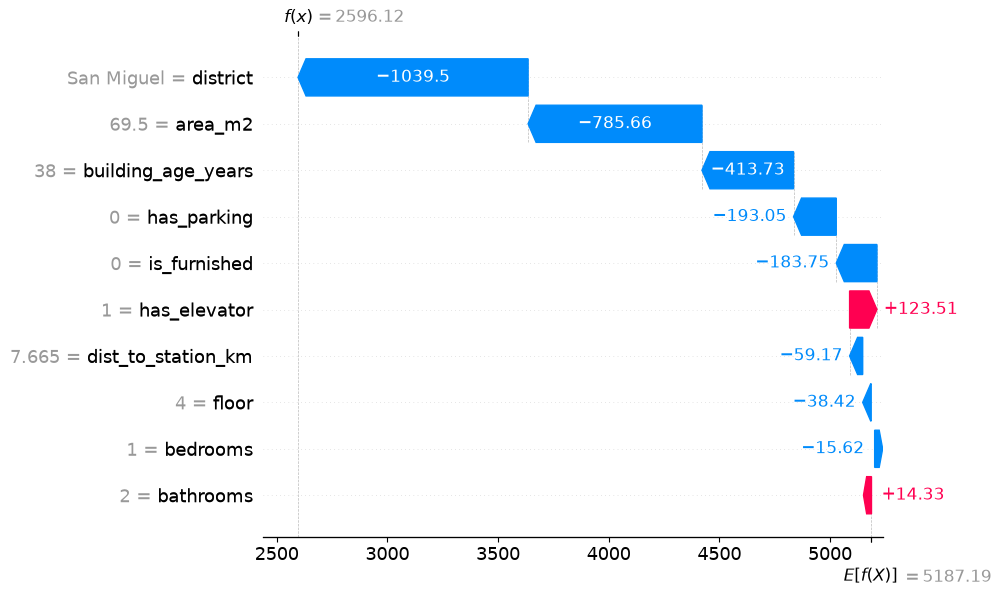

In [13]:
listing_idx = 0
listing_row = build_features(df.iloc[[listing_idx]])
predicted_price = artifact.model.predict(listing_row)[0]

print(f"Aviso: {df.iloc[listing_idx]['district']}, {df.iloc[listing_idx]['area_m2']} m²")
print(f"Precio real:    S/ {df.iloc[listing_idx]['price_pen']:,.0f}")
print(f"Precio predicho: S/ {predicted_price:,.0f}")

explainer = shap_explainer(artifact.model)
shap_values = explainer(listing_row)
shap_values.base_values = np.asarray(shap_values.base_values).reshape(-1)

import shap
shap.plots.waterfall(shap_values[0])


### TODO 4 — tu turno (no hay una respuesta única)

Mirando el waterfall de arriba, respondé en 2-3 líneas cada una:

1. **¿Qué empuja el precio hacia arriba?**

   _(tu respuesta acá)_

2. **¿Qué lo empuja hacia abajo?**

   _(tu respuesta acá)_

3. **¿Coincide con tu intuición como limeño/a?** ¿Hay algo que el modelo "cree" que a ti te sorprende?

   _(tu respuesta acá)_


---

## Y ahora ¿qué?

Esto fue una probadita. Quedó afuera a propósito: validación espacial, monitoreo de
drift, tuning de hiperparámetros en serio, tests exhaustivos, feature store — ver
`docs/guion_taller.md` para el porqué de cada uno.

Repo completo, con la API y el frontend en producción: [https://github.com/josefrodrim/lima-rent-ml](https://github.com/josefrodrim/lima-rent-ml)
